# Principal component analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Be able to implement PCA;
- Understand the properties of PCA;
- Understand the limitations of PCA;
- Understand how PCA can be used for dimensionality reduction.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

## (Optional) Exercise 1: applications of PCA
1. Find an interesting application of PCA and post a link to it (e.g., the blog post, article, podcast, video, etc.) on the Brightspace assignment forum of Week 03. Describe the application in several sentences. As the subject of your post, use a sensible title that explains the body: i.e., use a title like `group $<$number$>$: $<$your application$>$', where you fill in your group and the application you found.
1. Try to dig deep into your application. Please answer questions that come up on the forum. We might also ask you to answer questions that come up during the flipped-classroom session.
1. Interact with other groups by commenting on their posts. Elaborate on why you think their application is an interesting one (or not); would you want to know more about it (what and why)? Are there any parts that are unclear to you? Do you have any suggestions (e.g., other related sources of information)? Etc.

## Exercise 2: PCA overview
1. List and describe which computation steps are applied to the data when we do a Principal Component Analysis. You don't have to write the mathematical formulas but describe clearly what each step is doing. 

The overal goal of PCA is to reduce the dimensionality of the data. Often, the collected data is high dimensional and in order to be feasible for further processing steps, a reduction of dimensionality might be needed. Since some dimension contain and capture more information than others, the idea is to focus only on the dimensions that capture the most information and ignore the dimensions that do not.
PCA is a method of determining which dimensions should be kept and which dimensions can be reduced. The objective function, which determines the criterium used to decide which dimensions should be kept, can vary. In the lecture, it was assumed that the variance is an indicator for the relevance of a dimension. The dimensions of relevance (according to the objective function) are used to project the data into lower dimensions. The dimensions in this subspace should be chosen such that the data is uncorrelated.In order to perform PCA the following steps are taken:
Translation to origin:
The original data is not necessarily centered around the origin, so in this step the data is shifted to the origin.Rotation:
In this step, the principal components (PCs) are identified and the corresponding eigenvectors are computed. These eigenvectors are then used as new axes.Scaling:
The eigenvectors can have varying length after the previous step and in order to ensure comparability and feasability, the eigenvectors can be scaled based on their associated eigenvalues.
To go a little more into depth, the identification of the PCs is done based on the objective function. As mentioned above, this function strives to maximize the variance of the dimensions because the variance is assumed to be a good indicator for the relevance of the dimension.In more mathematical terms, the objective function which maximizes the variance looks like this:
$$ 
\arg \max_{u_1, \lambda_1} (\mathbf{u}_1^T \mathbf{S} \mathbf{u}_1 + \lambda_1 (1- \mathbf{u}_1^T \mathbf{u}_1))
$$
Here, u1T​Su1​ is the term that actually maximizes the variance, while the term λ1​(1−u1T​u1​) scales the vector u1​.To solve the maximization problem, we need to find the points where the function equals 0. This is achieved by taking the partial derivatives. 
The partial derivative for λ1​ results in the unit vector quality.
The partial derivative for u1​ results in the equation
$$ 
\begin{align}
0 &= \mathbf{S} \mathbf{u}_1 - \lambda_1 \mathbf{u}_1 \\\
\mathbf{S} \mathbf{u}_1 &= \lambda_1 \mathbf{u}_1
\end{align}
$$
This is the eigenvector equation, so to solve this, the eigenvalues and eigenvectors need to be found. In mathematical terms, maximal variance is reached when u1​ is an eigenvector with λ1​ as its eigenvalue.
After having found the first eigenvector and corresponding eigenvalue, we can do this process iteratively to obtain further projection directions. It is important to make sure that all eigenvectors are orthogonal to each other.

## Exercise 3: principal components
Below we provided a two-dimensional dataset $X$ of $N_{samples} \times D_{features}$, where $D_{features}=2$. The data are already zero-mean (requirement for PCA) and unlabeled. 
1. Compute the covariance matrix of this data;
1. Compute the eigenvalue decomposition of the covariance matrix to find the PCs;
1. Plot the data as a scatter plot;
1. Plot the PCs on this scatter plot. **Hint:** The directions of the PCs are given by the eigenvectors of the sample covariance matrix. Scale length of the PCs using the square root of the eigenvalues of sample covariance matrix.
1. Why do the PCs point in these directions?

**Important note**: Computational complexity of calculating the eigenvalue decomposition grows cubically with the number of features. Therefore, iterative approaches for computing the PCs are prefered when dealing with high dimensional data.

In [4]:
X = np.loadtxt('data/PCA_1.data') #N(samp) x D(featur   200x2)
N_samples = X.shape[0]

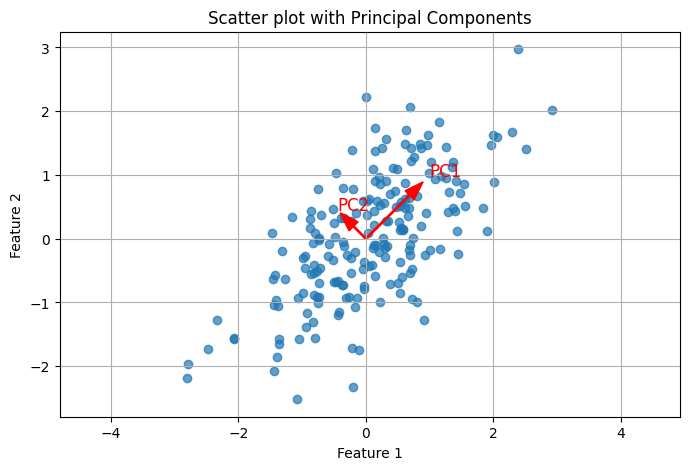

In [5]:
#X_centered = X - np.mean(X, axis=0) #The data are already zero-mean 
cov_matrix = np.cov(X, rowvar=False)

eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[sorted_indices]
eig_vecs_sorted = eig_vecs[:, sorted_indices]

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Scatter plot with Principal Components")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

for i in range(len(eig_vals_sorted)):
    vector = eig_vecs_sorted[:, i] * np.sqrt(eig_vals_sorted[i])
    plt.arrow(0, 0, vector[0], vector[1], 
              color='red', width=0.02, head_width=0.2, length_includes_head=True)
    plt.text(vector[0]*1.1, vector[1]*1.1, f'PC{i+1}', color='red', fontsize=12)

plt.grid(True)
plt.axis('equal')
plt.show()

The PCs point in the directions of maximum variance in the data. Each principal component is an eigenvector of the covariance matrix, and its length (eigenvalue) represents how much variance is explained along that direction. PCA finds axes that capture the most spread of the data.

## Exercise 4: how outliers and scaling of the data affect PCA
The following dataset is similar to the one analyzed before, however it contains outliers. Explore the PCs again in the presence of outliers.
1. Like in exercise 2, compute and plot the PCs together with the scatter plot of the data;`
1. Why and how is PCA prone to fail in the presence of outliers?
1. How does the scaling of the features affect PCA? For example: Using cm instead of meters. **Hint:** PCA uses variance of the data as criterion to find the PCs.

In [6]:
X = np.loadtxt('data/PCA_2.data')
N_samples = X.shape[0]

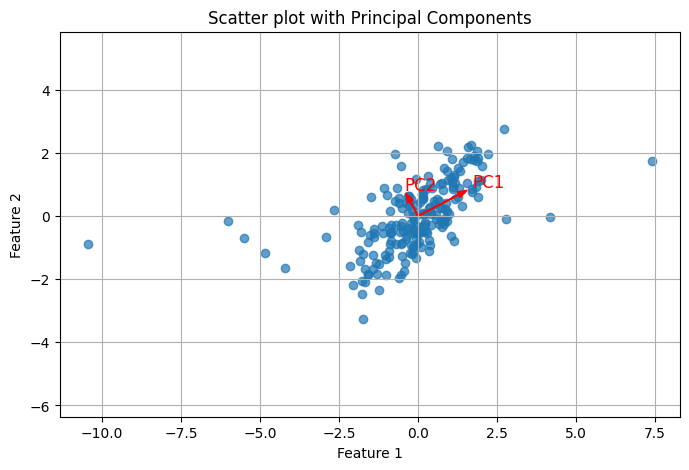

In [7]:
#X_centered = X - np.mean(X, axis=0) #The data are already zero-mean 
cov_matrix = np.cov(X, rowvar=False)

eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[sorted_indices]
eig_vecs_sorted = eig_vecs[:, sorted_indices]

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Scatter plot with Principal Components")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

for i in range(len(eig_vals_sorted)):
    vector = eig_vecs_sorted[:, i] * np.sqrt(eig_vals_sorted[i])
    plt.arrow(0, 0, vector[0], vector[1], 
              color='red', width=0.02, head_width=0.2, length_includes_head=True)
    plt.text(vector[0]*1.1, vector[1]*1.1, f'PC{i+1}', color='red', fontsize=12)

plt.grid(True)
plt.axis('equal')
plt.show()

1. Why and how is PCA prone to fail in the presence of outliers?  
Outliers strongly increase variance in their direction, which can shift the PCs toward the outliers and misrepresent the main structure of the data.

2. How does the scaling of the features affect PCA? For example: Using cm instead of meters. Hint: PCA uses variance of the data as criterion to find the PCs.  
PCA is sensitive to the scale of features because it uses variance to determine PCs. Features with larger scales dominate the variance. For example, if one feature is measured in meters and the other in centimeters, the variance of the second feature will be 100^2 times greater, and the main component will shift towards the second feature. Standardizing features avoids this problem.

## Exercise 5: dimensionality reduction with PCA as preprocessing for classification problems (1/2)
In the following exercise, we will see how PCA can be used to reduce the dimensionality of a dataset as a pre-processing stage for a classification task.
1. For this dataset, plot the PCs together with the scatter plot of the labelled data like in exercise 3. Now, becuase we have labeled data of two classes, set the color of each of the points according to its class;
1. Project the data onto each of the PCs and plot the projection (e.g. as histogram);
1. Which of the PCs is more adequate to perform dimensionality reduction in the labelled dataset?

In [9]:
X = np.loadtxt('data/PCA_3.data')
y = np.loadtxt('data/PCA_3.labels')
N_samples = X.shape[0]

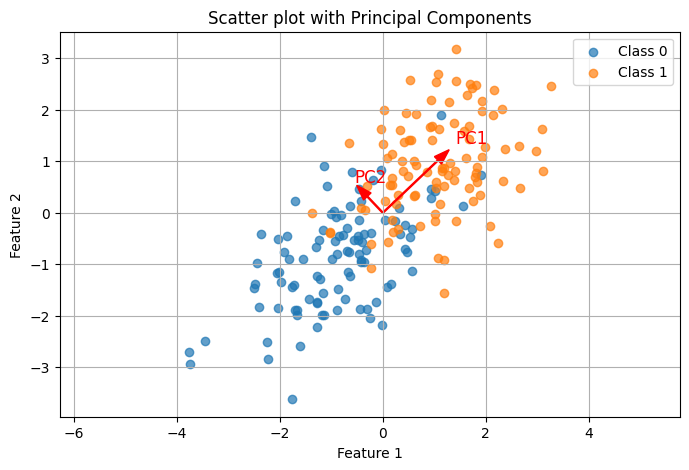

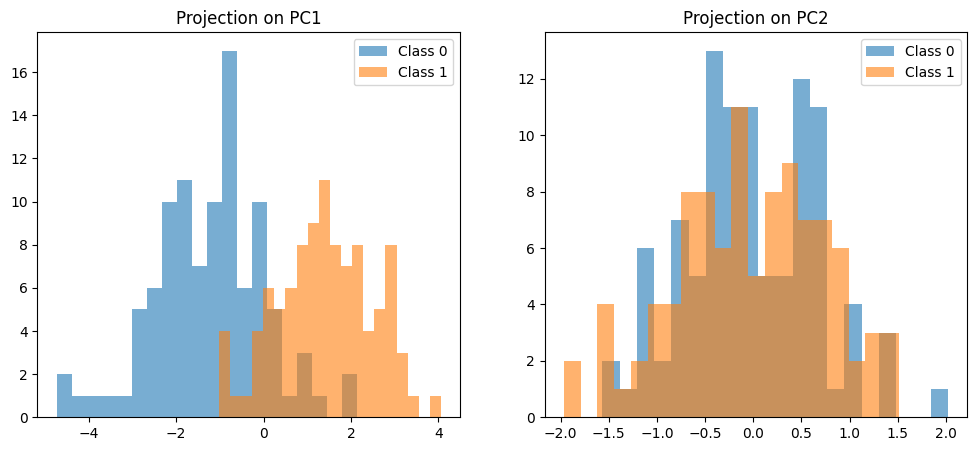

According to the histograms below, it is clear that the projection on PC1 projects the least overlap and
seems to be the most adequate option for dimensionality reduction, even though this may not be clear from looking at the scatterplot.


In [14]:
#X_centered = X - np.mean(X, axis=0) #The data are already zero-mean 
cov_matrix = np.cov(X, rowvar=False)

eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[sorted_indices]
eig_vecs_sorted = eig_vecs[:, sorted_indices]

plt.figure(figsize=(8, 5))
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)   c=цвет точек class y;    cmap='bwr' - цветовая схема (b,r,w=промежуточн знач)
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.7, label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.7, label="Class 1")

plt.title("Scatter plot with Principal Components")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

for i in range(len(eig_vals_sorted)):
    vector = eig_vecs_sorted[:, i] * np.sqrt(eig_vals_sorted[i])
    plt.arrow(0, 0, vector[0], vector[1], 
              color='red', width=0.02, head_width=0.2, length_includes_head=True)
    plt.text(vector[0]*1.1, vector[1]*1.1, f'PC{i+1}', color='red', fontsize=12)

plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

X_pca = X @ eig_vecs_sorted    #данные спроецированы на новые оси(главн компоненты) 
#X_projected[:, 0] – это проекция на PC1           X_projected[:, 1] – на PC2.

plt.figure(figsize=(12, 5))
for i in range(X_pca.shape[1]):    #X_pca.shape[1] - количество главных компонент (столбцов
    plt.subplot(1, 2, i+1)    # создает 1 строку, 2 колонки графиков
    plt.hist(X_pca[y==0, i], bins=20, alpha=0.6, label="Class 0")    # берет i-ю компоненту ТОЛЬКО для класса 0
    plt.hist(X_pca[y==1, i], bins=20, alpha=0.6, label="Class 1")
    plt.title(f"Projection on PC{i+1}")
    plt.legend()
plt.show()

print("According to the histograms below, it is clear that the projection on PC1 projects the least overlap and")
print("seems to be the most adequate option for dimensionality reduction, even though this may not be clear from looking at the scatterplot.")


    направление максимальной дисперсии (PC1) случайно совпало с направлением наилучшего разделения классов
    PC1 захватил большую часть информации, включая различия между классами
    PC2 содержит меньше дисперсии и почти не разделяет классы

    PCA - НЕСМОТРЯЩИЙ НА КЛАССЫ метод
    PCA слеп к меткам - он оптимизирует только дисперсию
    Для классификации иногда менее информативная компонента (PC2) может лучше разделять классы
    В Exercise 6 вам нужно выбрать PC2 для классификации, хотя она объясняет меньше общей дисперсии
    
    Если цель - классификация, иногда лучше использовать LDA (Linear Discriminant Analysis), который специально максимизирует разделение между классами, а не общую дисперсию.


## Exercise 6: dimensionality reduction with PCA as preprocessing for classification problems (2/2)
This exercise is similar to exercise 5, but with a different dataset. For questions 1. and 2., re-use the same code as previously.
1. For this dataset, plot the PCs together with the scatter plot of the labelled data like in exercise 3. Set the color of each of the points according to its class;
1. Project the data onto each of the PCs and plot the projection (e.g. as histogram);
1. What is the most relevant PC in this case, given that the goal is to perform dimensionality reduction for a classification task? Please, also compare your answer to exercise 4.

In [17]:
X = np.loadtxt('data/PCA_4.data')
y = np.loadtxt('data/PCA_4.labels')
N_samples = X.shape[0]

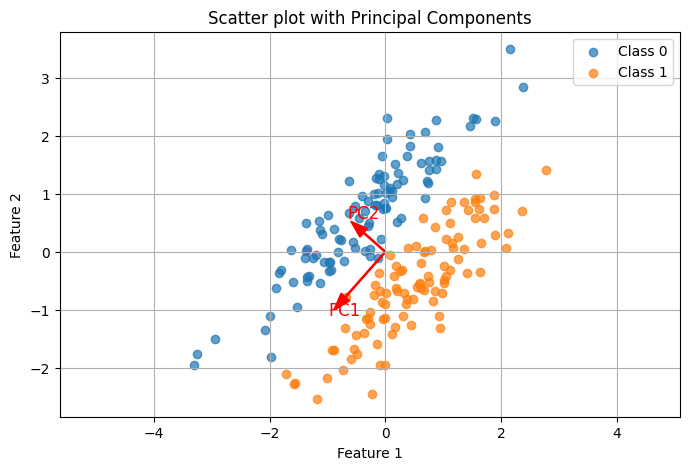

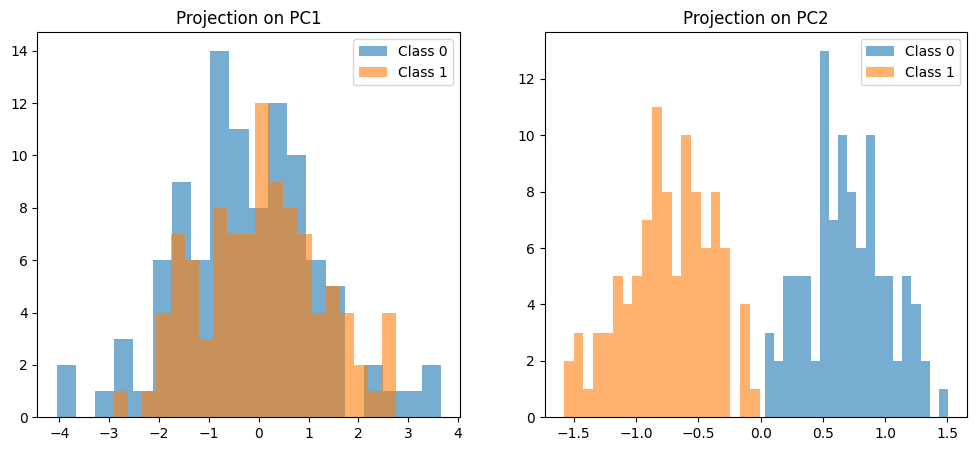

What is the most relevant PC in this case, given that the goal is to perform dimensionality reduction for a classification task? Please, also compare your answer to exercise 4.
For this dataset, it seems that PC2 is the most relevant if our goal is to perform dimensionality reduction. There is significantly less overlap between the two classes as is shown in the histogram.


In [19]:
#X_centered = X - np.mean(X, axis=0) #The data are already zero-mean 
cov_matrix = np.cov(X, rowvar=False)
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[sorted_indices]
eig_vecs_sorted = eig_vecs[:, sorted_indices]

plt.figure(figsize=(8, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.7, label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.7, label="Class 1")
plt.title("Scatter plot with Principal Components")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

for i in range(len(eig_vals_sorted)):
    vector = eig_vecs_sorted[:, i] * np.sqrt(eig_vals_sorted[i])
    plt.arrow(0, 0, vector[0], vector[1], 
              color='red', width=0.02, head_width=0.2, length_includes_head=True)
    plt.text(vector[0]*1.1, vector[1]*1.1, f'PC{i+1}', color='red', fontsize=12)

plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

X_pca = X @ eig_vecs_sorted    #данные спроецированы на новые оси(главн компоненты) 
#X_projected[:, 0] – это проекция на PC1           X_projected[:, 1] – на PC2.

plt.figure(figsize=(12, 5))
for i in range(X_pca.shape[1]):    #X_pca.shape[1] - количество главных компонент (столбцов
    plt.subplot(1, 2, i+1)    # создает 1 строку, 2 колонки графиков
    plt.hist(X_pca[y==0, i], bins=20, alpha=0.6, label="Class 0")    # берет i-ю компоненту ТОЛЬКО для класса 0
    plt.hist(X_pca[y==1, i], bins=20, alpha=0.6, label="Class 1")
    plt.title(f"Projection on PC{i+1}")
    plt.legend()
plt.show()

print("What is the most relevant PC in this case, given that the goal is to perform dimensionality reduction for a classification task? Please, also compare your answer to exercise 4.")
print("For this dataset, it seems that PC2 is the most relevant if our goal is to perform dimensionality reduction. There is significantly less overlap between the two classes as is shown in the histogram.")


    Здесь максимальная дисперсия НЕ совпадает с направлением разделения классов!
        * PC1 захватывает общую форму и разброс данных, но оба класса смешаны вдоль этой оси
        * PC2 содержит МЕНЬШЕ общей дисперсии, но именно вдоль этой оси классы идеально разделяются
        * PCA "не знает" о метках классов - он просто ищет направления максимальной дисперсии

       One PC yields better class separability on the histograms, while the other shows large within-class variance and heavy overlap. Since PCA is an unsupervised method that optimized variance, not class separability; as such, a direction that explains large variance is not guaranteed to be the best for classification. 
    
    PCA - НЕСМОТРЯЩИЙ НА КЛАССЫ мето -  PCA слеп к меткам - он оптимизирует только дисперсию
    Для классификации иногда менее информативная компонента (PC2) может лучше разделять классы
    В Exercise 6 вам нужно выбрать PC2 для классификации, хотя она объясняет меньше общей дисперсии
    
    Если цель - классификация, иногда лучше использовать LDA (Linear Discriminant Analysis), который специально максимизирует разделение между классами, а не общую дисперсию.

## Exercise 7: PCA for dimensionality reduction: Selecting the number of PC in a high dimensional dataset
In this exercise, we will explore the criteria that might be used to select the number of components for a dimensionality reduction task using PCA.
1. Compute the PCs;
1. Plot the eigenvalue spectrum (e.g., using the `plt.stem()` function);
1. By visually inspecting the eigenvalue spectrum of the covariance matrix, how many components do you think are necessary to achieve a good representation of the variance of the data? **Hint:** The magnitude of the eigenvalues represents the contribution of the corresponding PC to the variance of the data.


In [21]:
X = np.loadtxt('data/PCA_5.data')
N_samples = X.shape[0]

(100, 100)


<function matplotlib.pyplot.show(close=None, block=None)>

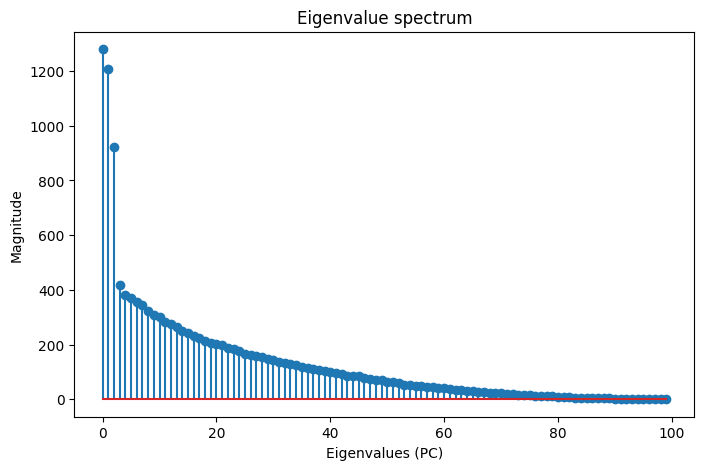

In [22]:
# 1. centering of data and computing the eigenvalues
X_centered = X - np.mean(X, axis=0)  #X — матрица данных размером N_samples × D_features.
cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix.shape) # 100 x 100 -> 100 eigenvalues  ===100 признаков, и будет столько же собственных значений (eigenvalues).

eigen_vals, eigen_vecs = np.linalg.eigh(cov_matrix)  # eigh() only works for symmetric matrices but since a covariance matrix is by definition symmetric, eigh() can be used
 # Собственные значения (eigenvalues) = величина дисперсии, которую объясняет соответствующая главная компонента.
 # Собственные векторы (eigenvectors) = направления (оси), вдоль которых лежат эти компоненты.
     
sorted_indices = np.argsort(eigen_vals)[::-1]     # PCA упорядочивает компоненты по тому, сколько они объясняют дисперсии.
eigen_vals_sorted = eigen_vals[sorted_indices]
eigen_vecs_sorted = eigen_vecs[:, sorted_indices]


# 2. eigenvalue spectrum
plt.figure(figsize=(8, 5))
plt.stem(eigen_vals_sorted)      #  Строим eigenvalue spectrum: столбчатый график, где каждый "стержень" = собственное значение.
plt.title("Eigenvalue spectrum")   #   Чем выше значение, тем больше вариации данных описывает эта компонент
plt.xlabel("Eigenvalues (PC)")
plt.ylabel("Magnitude")
plt.show

    "Какие компоненты нужны для хорошего представления дисперсии?"
   
    Переформулировка: PCA ищет такие новые оси, чтобы по первым осям данные менялись максимально(вариация).
    Собственные значения показывают, сколько информации (вариации=важности признаков) мы сохраняем, если берём эту компоненту.
    Если посмотреть на график (eigenvalue spectrum), видно:
      * Первые 3 значения большие → они объясняют большую часть дисперсии.
      * Начиная с 4-го значения, eigenvalues маленькие → добавляют мало информации.

Если хочется чуть больше информации, можно рассмотреть до 10 компонентов, но выигрыш будет маленький.
Тем не менее, если уменьшение размеров не слишком важно, возможно, стоит рассмотреть возможность использования первых 10 ПК, но опять же, после первых 3 ПК количество дополнительно объясняемых отклонений на ПК будет намного меньше, поэтому, возможно, не стоит использовать дополнительные размеры.

## Exercise 8: PCA for dimensionality reduction: Selecting the number of PC in a high dimensional dataset
Visually inspecting the eigenvalue spectrum of the covariance matrix does not always provide a clear criterion for the selection of the number of relevant components (i.e., it is subjective). If that is the case, an alternative criterion might be used: Typically, the number of PC is selected so as to achieve approximately 90% of accumulated variance. 
**Note:** This this is only a rule of thumb, values of 95% or 99% are also often seen.

1. (Optional) Using the cumulative variance criterion, how many components should be selected for performing dimensionality reduction in the following dataset? **Hint:** The eigenvalues represent the variance explained by the corresponding PC.

In [ ]:
X = np.loadtxt('data/PCA_6.data')
N_samples = X.shape[0]

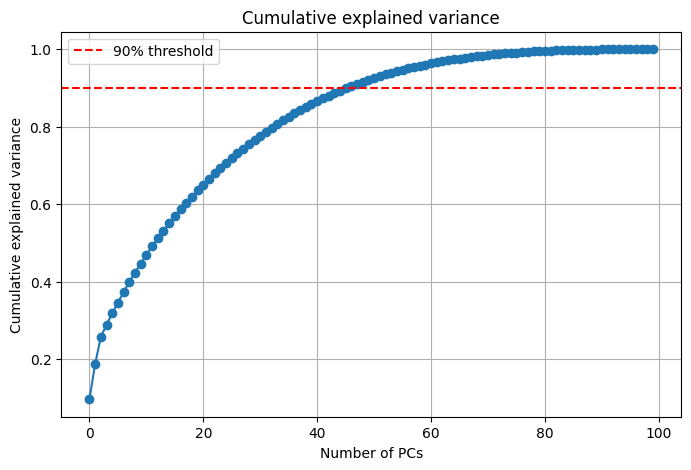

Number of components to reach 90% variance: 47
PCs needed for 90% variance: 47
PCs needed for 95% variance: 57
PCs needed for 99% variance: 75


In [26]:
# 1. Центрируем данные и строим ковариационную матрицу
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)

# 2. Собственные значения и векторы
eigen_vals, eigen_vecs = np.linalg.eigh(cov_matrix)

# 3. Сортировка по убыванию
sorted_indices = np.argsort(eigen_vals)[::-1]
eigen_vals_sorted = eigen_vals[sorted_indices]

# 4. Доля объясненной дисперсии каждой компонентой 
# Каждое собственное значение делим на сумму всех → получаем, сколько процентов общей вариации объясняет этот PC.
total_var = eigen_vals.sum()
explained_variance_ratio = eigen_vals_sorted / total_var

# 5. Накопленная сумма объясненной дисперсии
cumulative_variance = np.cumsum(explained_variance_ratio)

# 6. Визуализация не наджо ыбло делать ваще
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label="90% threshold")
plt.title("Cumulative explained variance")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

# 7. Определяем, сколько компонентов нужно для 90%
  # показывает, сколько суммарно объясняют первые k компонент. 
num_components_90 = np.argmax(cumulative_variance >= 0.9) + 1   # находит первый индекс, где доля ≥ 90%.
print(f"Number of components to reach 90% variance: {num_components_90}") №

#-------------------------------------------
def pcs_for_threshold(cum, threshold=0.90):
	return int(np.searchsorted(cum, threshold) + 1)

k90 = pcs_for_threshold(cumulative_variance, 0.90)
k95 = pcs_for_threshold(cumulative_variance, 0.95)
k99 = pcs_for_threshold(cumulative_variance, 0.99)

print(f"PCs needed for 90% variance: {k90}")
print(f"PCs needed for 95% variance: {k95}")
print(f"PCs needed for 99% variance: {k99}")

    Используя критерий накопленной дисперсии, для данного набора данных необходимо взять N компонентов, чтобы объяснить не менее 90% общей вариации.
    Это число определяется как точка, где кумулятивная кривая впервые пересекает уровень 0.9 (90%)

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here